Codebase Summary

The codebase implements the full workflow for stellar object classification, covering data preparation, exploratory analysis, model development, evaluation, and interpretation. It serves as the backbone of the project, ensuring reproducibility and allowing systematic comparison across multiple machine-learning algorithms.

Key Components of the Codebase

Data Loading & Cleaning:
Imports the dataset, checks structure, handles missing values, and prepares all features for analysis.

Exploratory Data Analysis (EDA):
Visualizes distributions, correlations between features, and patterns across object classes (GALAXY, STAR, QSO).

Preprocessing Pipeline:

Performs outlier handling.


Model Implementations:
Includes full training pipelines for:

Logistic Regression

Decision Tree

Random Forest

K-Nearest Neighbours (KNN)

Support Vector Machine (SVM)

Gradient Boosting

AdaBoost

XGBoost


Evaluation Metrics:
Computes accuracy, precision, recall, F1-score, confusion matrix, classification report for each model.

Performance Comparison:
Generates a consolidated results table and visual comparison of model accuracy across algorithms.

Error Analysis:
Interprets misclassification patterns and examines reasons behind model performance differences.



In [ ]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
star_data = pd.read_csv("star_classification.csv")

In [ ]:
star_data.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
star_data.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [ ]:
star_data.shape

(100000, 18)

In [ ]:
star_data.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [ ]:
star_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
star_data.isnull().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


In [ ]:
columns = ['obj_ID', 'run_ID', 'rerun_ID', 'field_ID', 'spec_obj_ID', 'fiber_ID']

# Loop through the column names and calculate unique values for each
for col in columns:
    unique_count = star_data[col].nunique()
    print(f"The unique values in {col} are {unique_count}")

The unique values in obj_ID are 78053
The unique values in run_ID are 430
The unique values in rerun_ID are 1
The unique values in field_ID are 856
The unique values in spec_obj_ID are 100000
The unique values in fiber_ID are 1000


In [ ]:
star_data.drop(columns= columns, axis= 1, inplace= True)

In [ ]:
star_data.head()

,alpha,delta,u,g,r,i,z,cam_col,class,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,GALAXY,0.634794,5812,56354
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,GALAXY,0.779136,10445,58158
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,GALAXY,0.644195,4576,55592
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,GALAXY,0.932346,9149,58039
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,GALAXY,0.116123,6121,56187


In [ ]:
star_data.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col', 'class',
       'redshift', 'plate', 'MJD'],
      dtype='object')

In [ ]:
star_data['cam_col'].unique()

array([2, 5, 3, 4, 6, 1])

In [ ]:
data = star_data.drop(columns='class', axis= 1)
data.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,2,0.634794,5812,56354
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,5,0.779136,10445,58158
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,2,0.644195,4576,55592
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,3,0.932346,9149,58039
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3,0.116123,6121,56187


In [ ]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [ ]:
data

array([[0.37690482, 0.50380246, 0.99911256, ..., 0.09183086, 0.45159189,
        0.64800655],
       [0.40228576, 0.49181212, 0.99920216, ..., 0.11238889, 0.8288413 ,
        0.89432004],
       [0.39495978, 0.53413882, 0.99925055, ..., 0.09316979, 0.35094862,
        0.54396505],
       ...,
       [0.62384846, 0.33880973, 0.99884246, ..., 0.02183899, 0.20340363,
        0.399645  ],
       [0.58962907, 0.6429744 , 0.99925925, ..., 0.06622931, 0.52805146,
        0.64991808],
       [0.54692681, 0.67052516, 0.99898725, ..., 0.07874916, 0.58171159,
        0.75040961]])

In [ ]:
data = pd.DataFrame(data= data, columns= ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col',
       'redshift', 'plate', 'MJD'])

In [ ]:
data.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.2,0.091831,0.451592,0.648007
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.8,0.112389,0.828841,0.894320
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.2,0.093170,0.350949,0.543965
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.4,0.134210,0.723312,0.878072
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.4,0.017959,0.476753,0.625205


In [ ]:
data['class'] = star_data['class']

In [ ]:
data.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD,class
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.2,0.091831,0.451592,0.648007,GALAXY
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.8,0.112389,0.828841,0.894320,GALAXY
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.2,0.093170,0.350949,0.543965,GALAXY
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.4,0.134210,0.723312,0.878072,GALAXY
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.4,0.017959,0.476753,0.625205,GALAXY


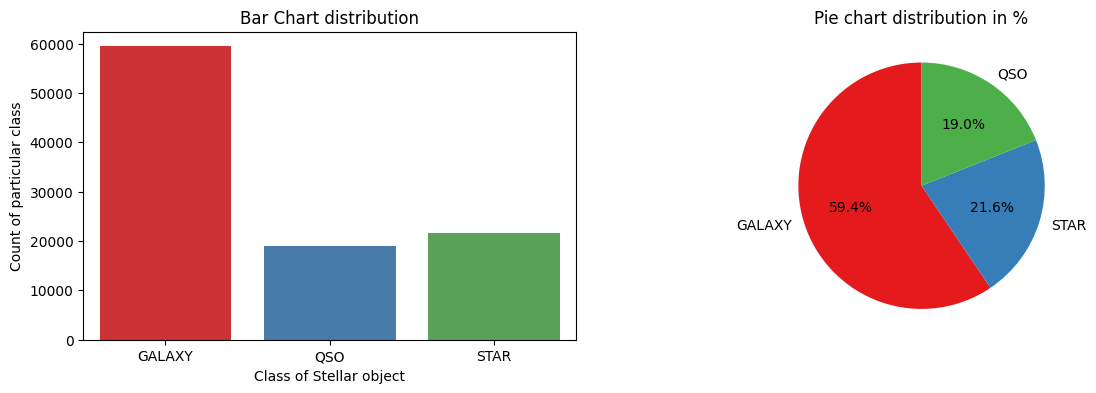

In [ ]:
plt.figure(figsize= (14,4))

plt.subplot(1,2,1)
palette_colors = sns.color_palette("Set1")
ax = sns.countplot(data= data, x= 'class', palette= palette_colors)
plt.xlabel("Class of Stellar object")
plt.ylabel("Count of particular class")
plt.title("Bar Chart distribution")


plt.subplot(1,2,2)
distribution = data['class'].value_counts()
plt.pie(x=distribution, labels= distribution.index, autopct= '%1.1f%%', startangle=90, colors= sns.color_palette('Set1') )
plt.title("Pie chart distribution in %")
plt.show()

In [ ]:
data['class'] = data['class'].map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})
data.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD,class
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.2,0.091831,0.451592,0.648007,0
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.8,0.112389,0.828841,0.894320,0
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.2,0.093170,0.350949,0.543965,0
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.4,0.134210,0.723312,0.878072,0
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.4,0.017959,0.476753,0.625205,0


### Outlier Analysis

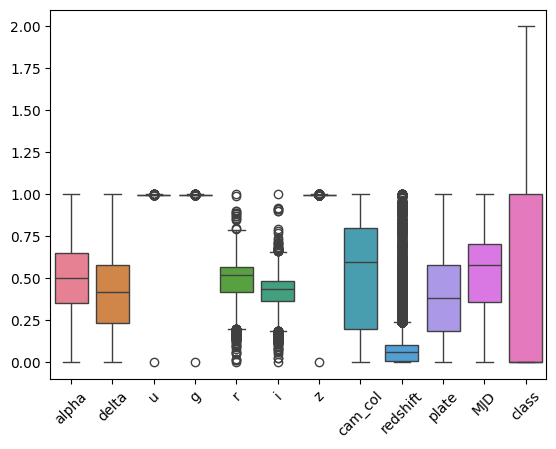

In [ ]:
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()

From the above plot we can see there are ouliers in the columns 'u', 'g', 'r', 'i', 'z', and more in 'red shift'. Let us try to remove them.

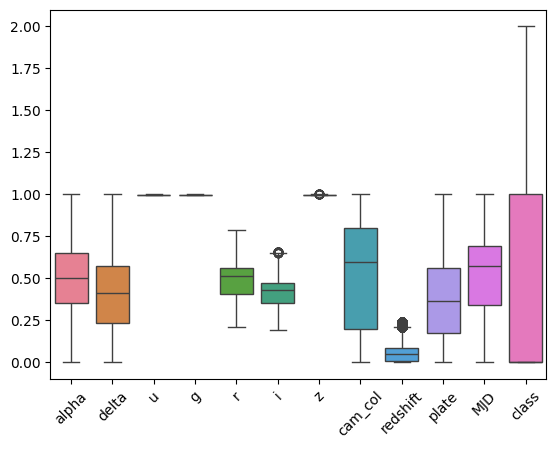

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered_df = df[(df[column] >= lower) & (df[column] <= upper)]
    return filtered_df

data_clean = data.copy()

for col in data_clean.select_dtypes(include='number').columns:
    data_clean = remove_outliers(data_clean, col)

sns.boxplot(data=data_clean)
plt.xticks(rotation=45)
plt.show()

In [ ]:
removed_percent = ((data.shape[0] - data_clean.shape[0]) / data.shape[0]) * 100
print(f'Percentage of outliers removed from the data set is {removed_percent}%')

Percentage of outliers removed from the data set is 9.4%


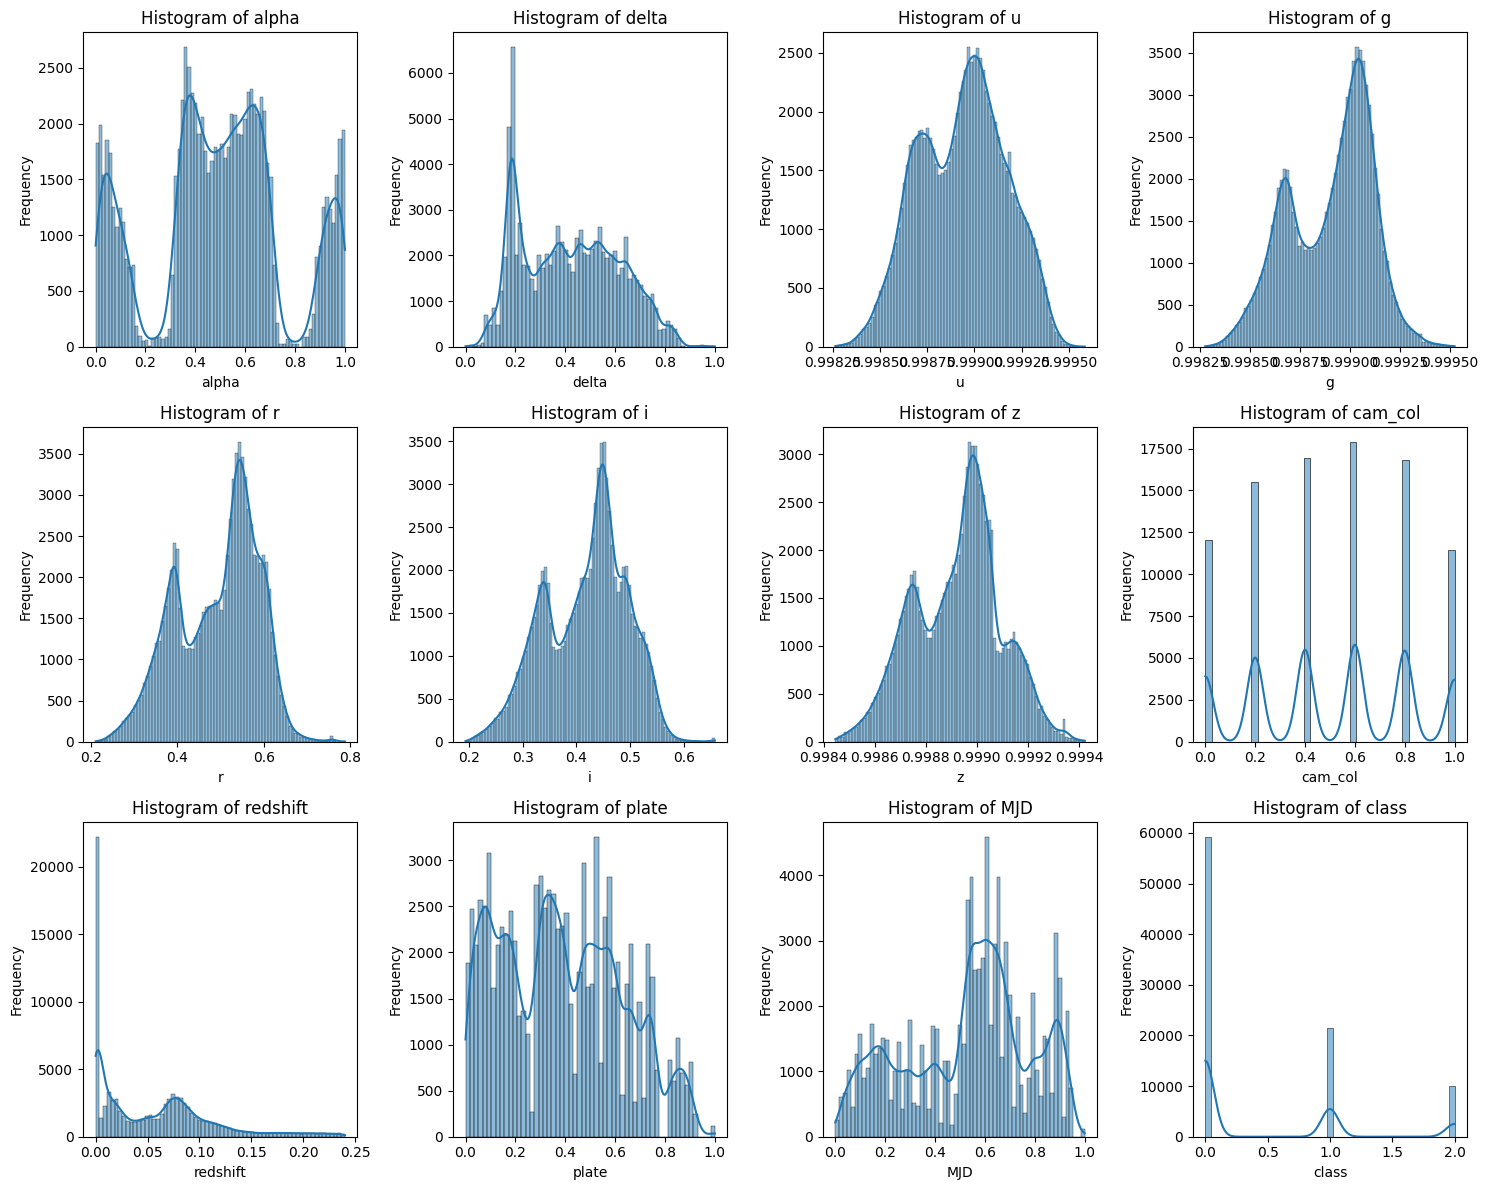

In [ ]:
import math

# Select numeric columns from the dataset
numeric_columns = data_clean.select_dtypes(include='number').columns

# Calculate the number of rows needed based on the number of columns
n_cols = 4
n_rows = math.ceil(len(numeric_columns) / n_cols)

# Set up the subplot grid with 3 columns
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 4))

# Flatten axes in case it's a 2D array
axes = axes.flatten()

# Create a histogram for each numeric column
for i, col in enumerate(numeric_columns):
    sns.histplot(data_clean[col], ax=axes[i], kde=True)  # Plot with KDE curve
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots, if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
data_clean.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'cam_col', 'redshift',
       'plate', 'MJD', 'class'],
      dtype='object')

### Bivariate Analysis

In [ ]:
columns1 = ['alpha', 'delta', 'u', 'g', 'r', 'class']
columns2 = ['i', 'z', 'cam_col', 'redshift', 'plate', 'MJD', 'class']

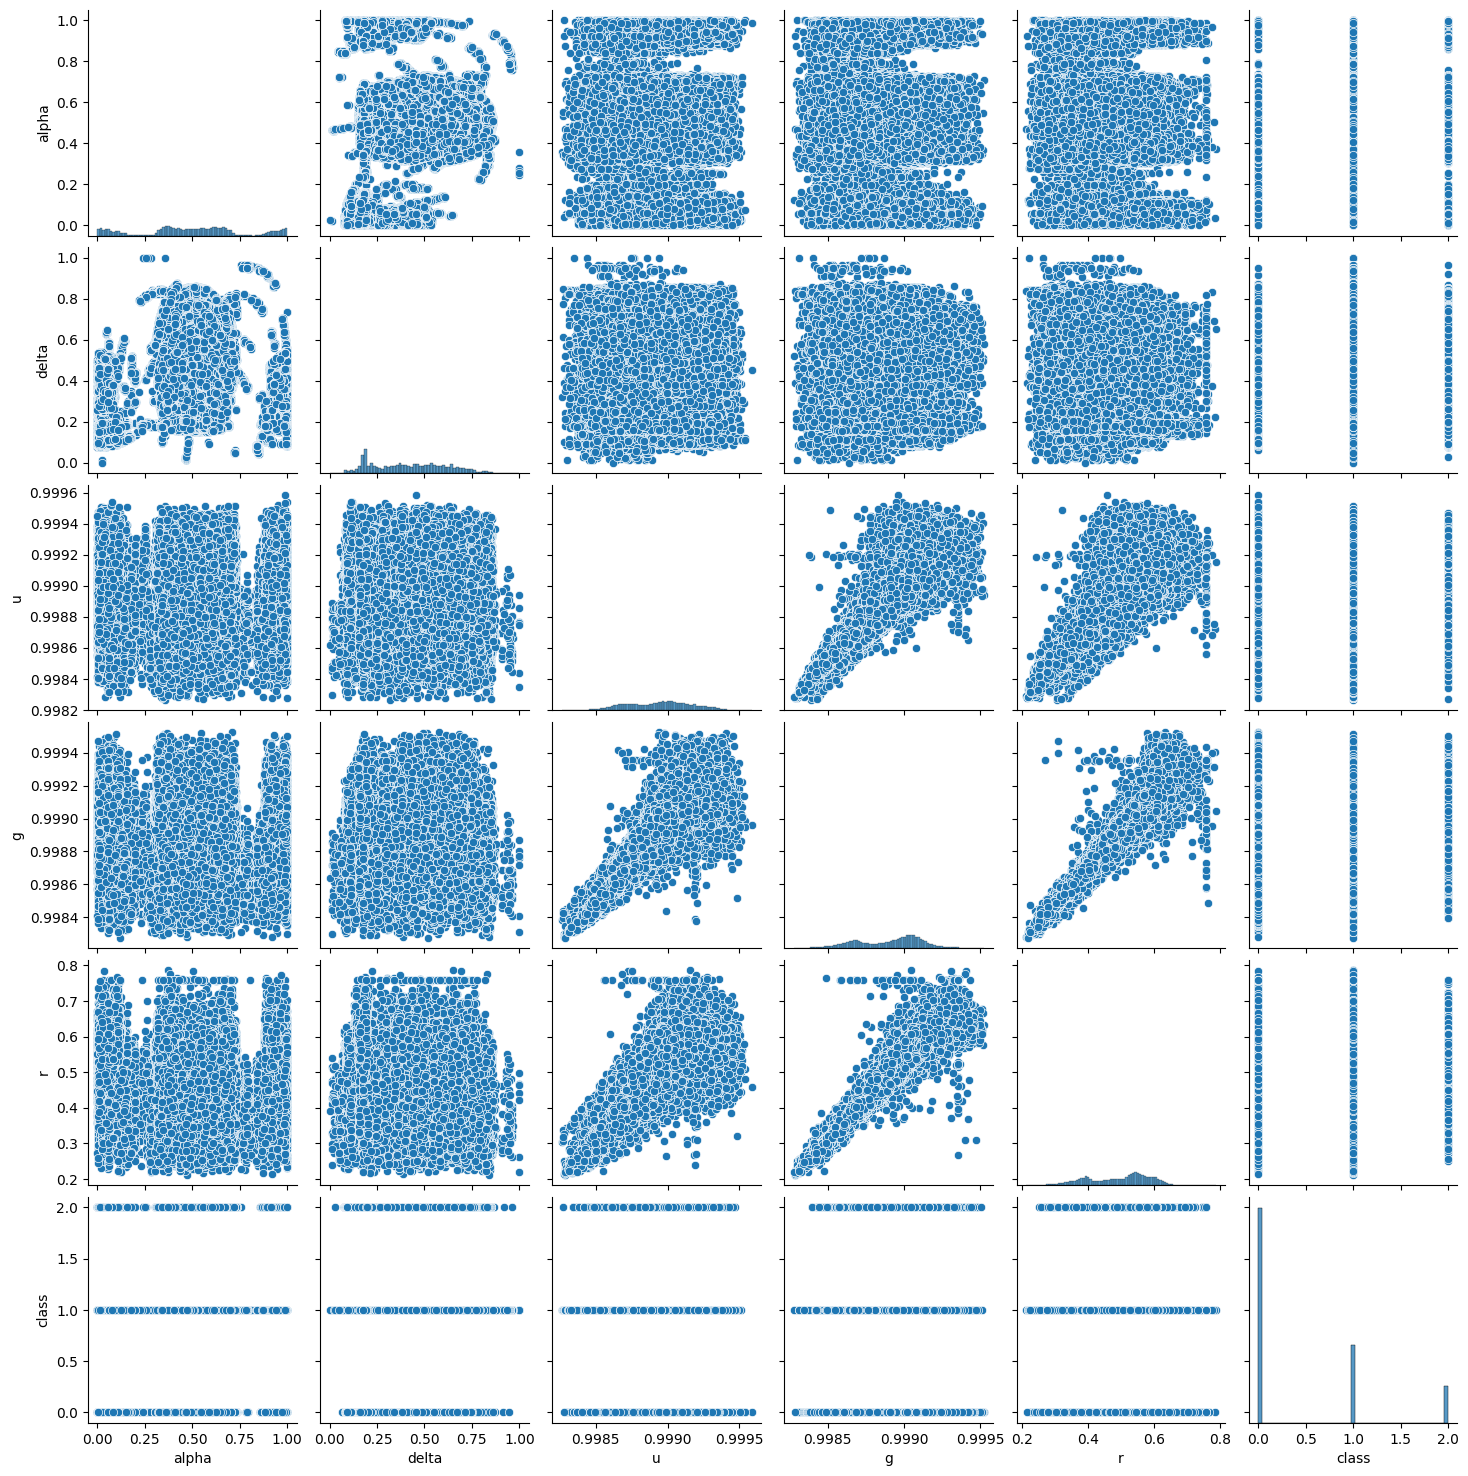

In [ ]:
sns.pairplot(data=data_clean[columns1])
plt.show()

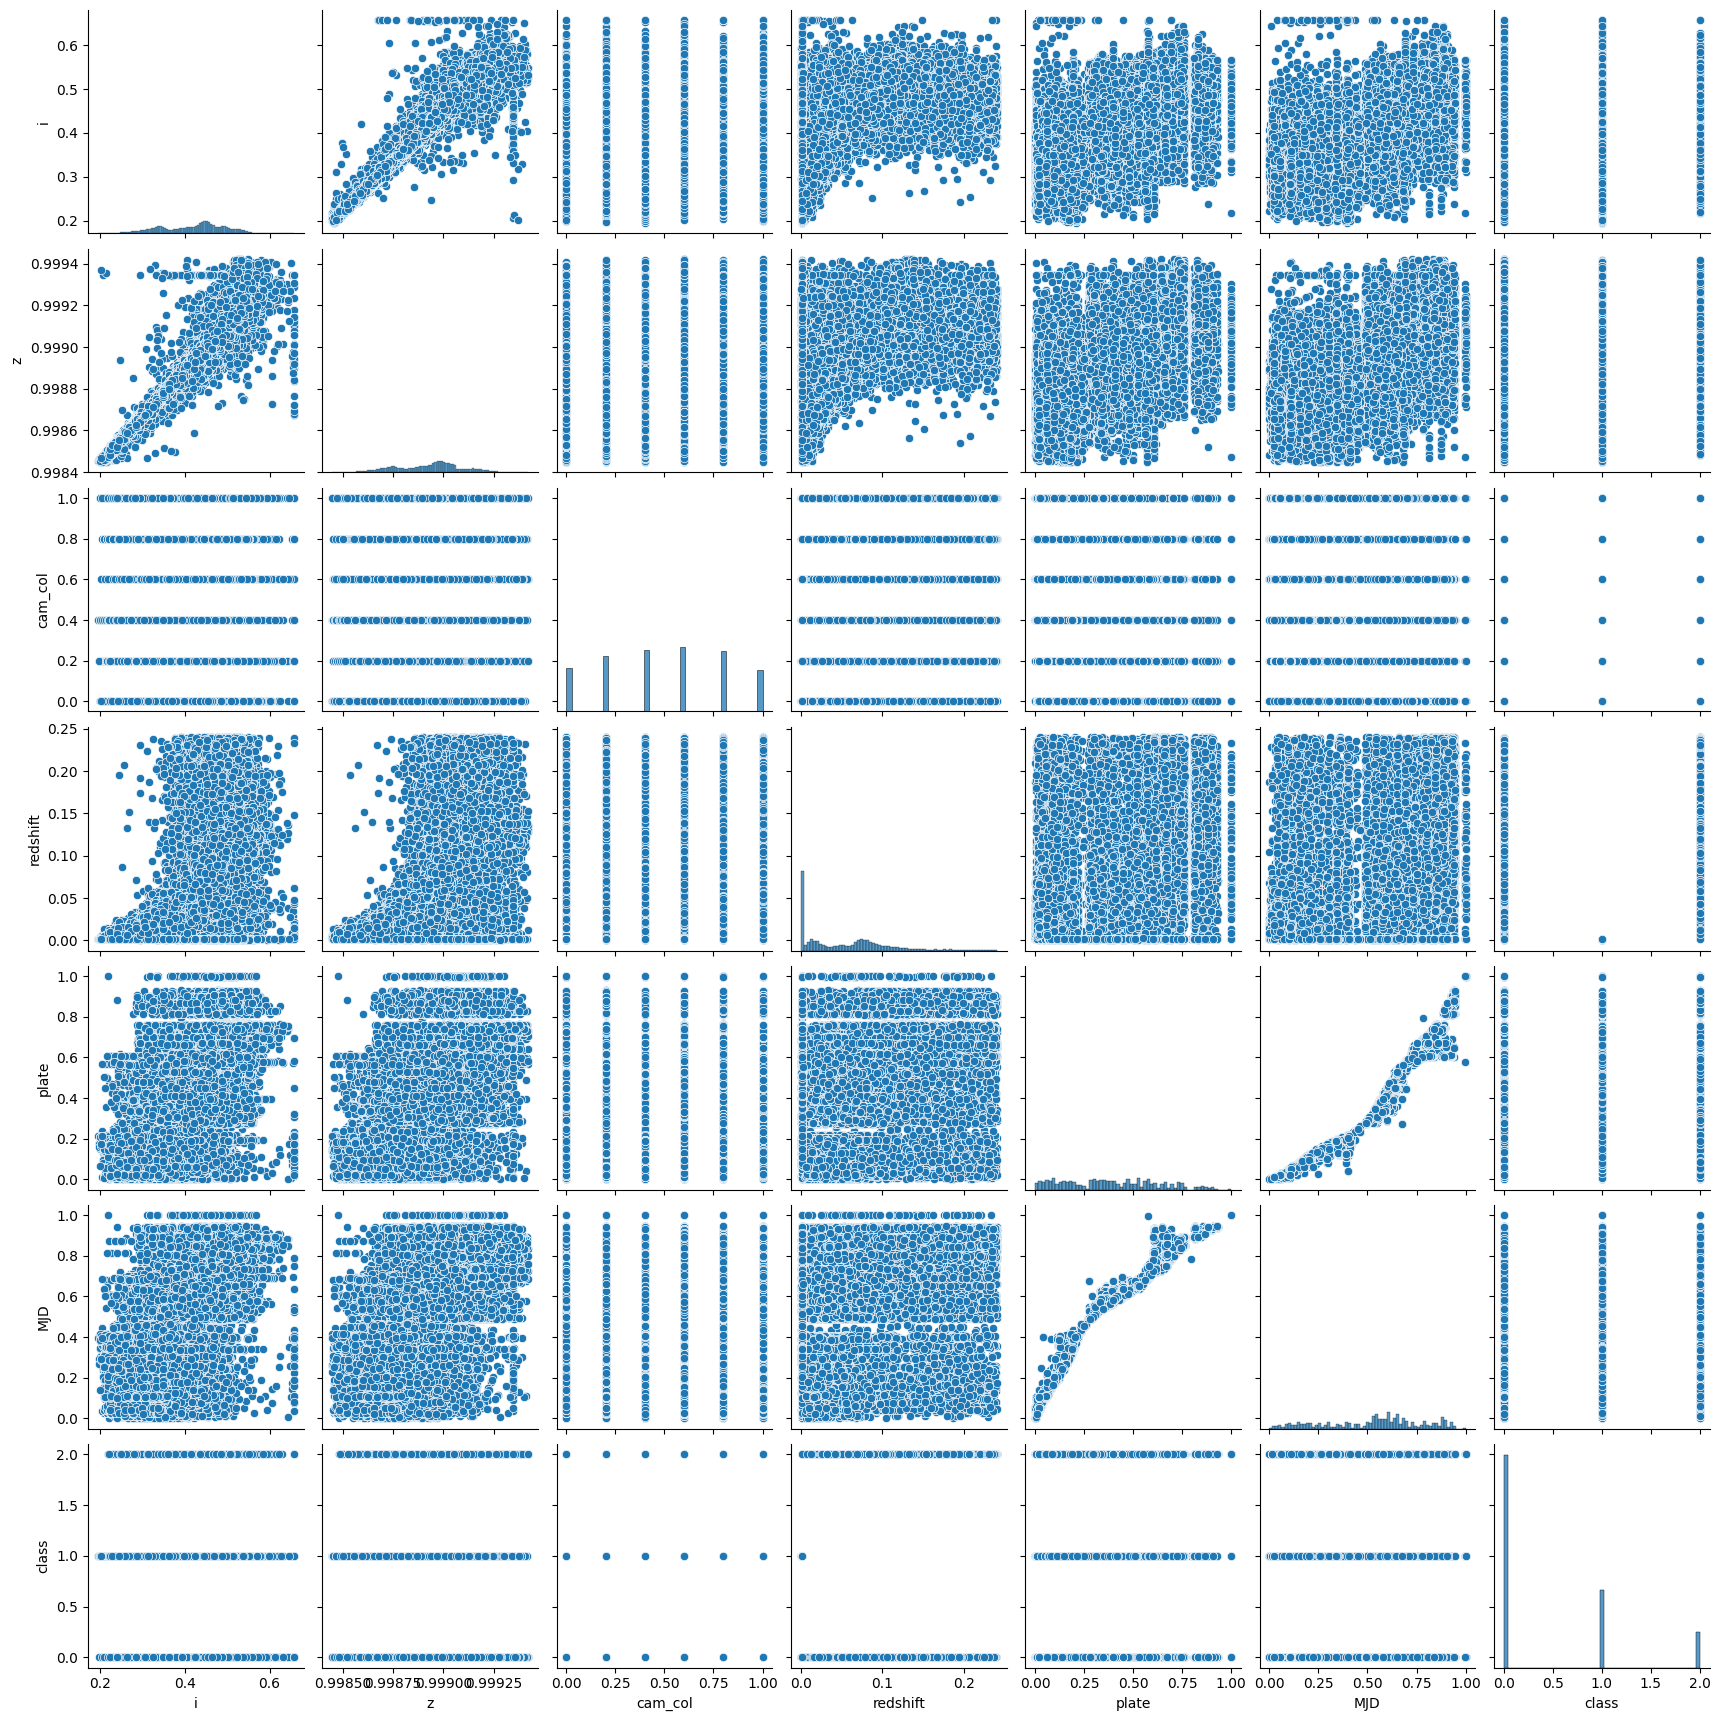

In [ ]:
sns.pairplot(data=data_clean[columns2])
plt.show()

In [ ]:
data_clean.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD,class
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.2,0.091831,0.451592,0.648007,0
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.8,0.112389,0.828841,0.894320,0
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.2,0.093170,0.350949,0.543965,0
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.4,0.134210,0.723312,0.878072,0
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.4,0.017959,0.476753,0.625205,0


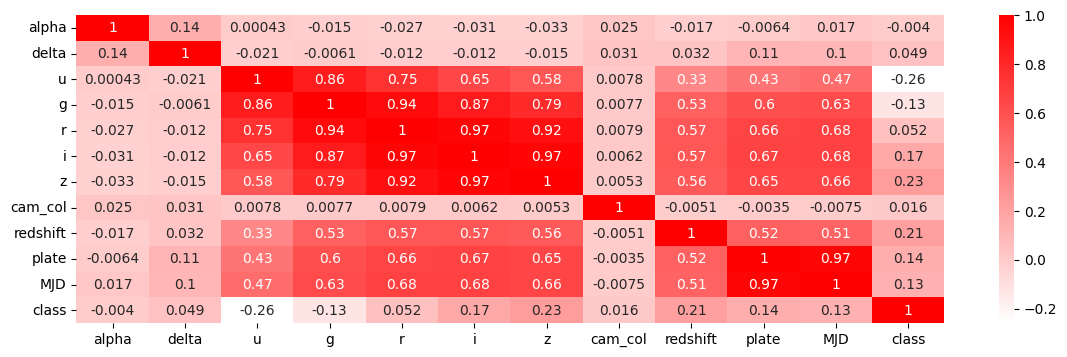

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

correl = data_clean.corr()

plt.figure(figsize= (14,4))

# Define a custom single-color colormap
single_color_cmap = LinearSegmentedColormap.from_list("single_color", ["white", "red"])

# Plot the heatmap with the custom colormap
sns.heatmap(correl, cmap=single_color_cmap, annot=True)
plt.show()

In [ ]:
X = data_clean.drop('class', axis = 1)
y = data_clean['class']
X.head()

,alpha,delta,u,g,r,i,z,cam_col,redshift,plate,MJD
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.2,0.091831,0.451592,0.648007
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.8,0.112389,0.828841,0.894320
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.2,0.093170,0.350949,0.543965
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.4,0.134210,0.723312,0.878072
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.4,0.017959,0.476753,0.625205


In [ ]:
y[0:10]

,class
0,0
1,0
2,0
3,0
4,0
5,2
6,2
7,0
8,0
9,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)
X_train.shape, y_train.shape

((67950, 11), (67950,))

# Model Development

### LogisticRegression

In [ ]:
model_LR = LogisticRegression()
model_LR.fit(X_train,y_train)
y_pred_LR = model_LR.predict(X_test)

In [ ]:
# LogisticRegression Evaluation
accuracy_LR = accuracy_score(y_test, y_pred_LR)

# Weighted precision and recall
precision_LR = precision_score(y_test, y_pred_LR, average='weighted')
recall_LR = recall_score(y_test, y_pred_LR, average='weighted')

# Class-wise precision and recall
precision_LR_class = precision_score(y_test, y_pred_LR, average=None)
recall_LR_class = recall_score(y_test, y_pred_LR, average=None)

f1_LR = f1_score(y_test, y_pred_LR, average= 'weighted')
confusion_LR = confusion_matrix(y_test, y_pred_LR)
classi_LR = classification_report(y_test, y_pred_LR)

model_name='LogisticRegression'
print(f"The Accuracy score for {model_name} is {accuracy_LR:.2f}")
print(f"The Weighted Precision score for {model_name} is {precision_LR:.2f}")
print(f"The Weighted Recall score for {model_name} is {recall_LR:.2f}")

# Print confusion matrix, classification report and f1_score
print(f"The F1 score for {model_name} is {f1_LR:.4f}")
print(f"The Confusion Matrix for {model_name} is \n{confusion_LR}")
print(f"The Classification Report for {model_name} is \n{classi_LR}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_LR_class[idx]:.2f}, Recall: {recall_LR_class[idx]:.2f}")


The Accuracy score for LogisticRegression is 0.91
The Weighted Precision score for LogisticRegression is 0.91
The Weighted Recall score for LogisticRegression is 0.91
The F1 score for LogisticRegression is 0.9078
The Confusion Matrix for LogisticRegression is 
[[14208   522   147]
 [  485  4780     0]
 [  854    18  1636]]
The Classification Report for LogisticRegression is 
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     14877
           1       0.90      0.91      0.90      5265
           2       0.92      0.65      0.76      2508

    accuracy                           0.91     22650
   macro avg       0.91      0.84      0.87     22650
weighted avg       0.91      0.91      0.91     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.91, Recall: 0.96
Class 1 - Precision: 0.90, Recall: 0.91
Class 2 - Precision: 0.92, Recall: 0.65


### Decision Tree Classifier

In [ ]:
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train,y_train)
y_pred_DT = model_DT.predict(X_test)

In [ ]:
# Decision Tree Evaluation
accuracy_DT = accuracy_score(y_test, y_pred_DT)

# Weighted precision and recall (due to class imbalance)
precision_DT = precision_score(y_test, y_pred_DT, average='weighted')
recall_DT = recall_score(y_test, y_pred_DT, average='weighted')

# Class-wise precision and recall
precision_DT_class = precision_score(y_test, y_pred_DT, average=None)
recall_DT_class = recall_score(y_test, y_pred_DT, average=None)

f1_DT = f1_score(y_test, y_pred_DT, average= 'weighted')
confusion_DT = confusion_matrix(y_test, y_pred_DT)
classi_DT = classification_report(y_test, y_pred_DT)

# Print weighted metrics
print(f"The Accuracy score for Decision Tree Classifier is {accuracy_DT:.2f}")
print(f"The Weighted Precision score for Decision Tree Classifier is {precision_DT:.2f}")
print(f"The Weighted Recall score for Decision Tree Classifier is {recall_DT:.2f}")

# Print confusion matrix, classification report and f1_score
print(f"The F1 score for Decision Tree Classifier is {f1_DT:.4f}")
print(f"The Confusion Matrix for Decision Tree Classifier is \n{confusion_DT}")
print(f"The Classification Report for Decision Tree Classifier is \n{classi_DT}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_DT_class[idx]:.2f}, Recall: {recall_DT_class[idx]:.2f}")


The Accuracy score for Decision Tree Classifier is 0.96
The Weighted Precision score for Decision Tree Classifier is 0.96
The Weighted Recall score for Decision Tree Classifier is 0.96
The F1 score for Decision Tree Classifier is 0.9590
The Confusion Matrix for Decision Tree Classifier is 
[[14387    19   471]
 [   22  5242     1]
 [  418     1  2089]]
The Classification Report for Decision Tree Classifier is 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     14877
           1       1.00      1.00      1.00      5265
           2       0.82      0.83      0.82      2508

    accuracy                           0.96     22650
   macro avg       0.93      0.93      0.93     22650
weighted avg       0.96      0.96      0.96     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.97, Recall: 0.97
Class 1 - Precision: 1.00, Recall: 1.00
Class 2 - Precision: 0.82, Recall: 0.83


### Random Forest Classifier

In [ ]:
model_RF = RandomForestClassifier()
model_RF.fit(X_train,y_train)
y_pred_RF = model_DT.predict(X_test)

In [ ]:
# Random Forest Evaluation
accuracy_RF = accuracy_score(y_test, y_pred_RF)

# Weighted precision and recall (due to class imbalance)
precision_RF = precision_score(y_test, y_pred_RF, average='weighted')
recall_RF = recall_score(y_test, y_pred_RF, average='weighted')

# Class-wise precision and recall
precision_RF_class = precision_score(y_test, y_pred_RF, average=None)
recall_RF_class = recall_score(y_test, y_pred_RF, average=None)

f1_RF = f1_score(y_test, y_pred_RF, average='weighted')
confusion_RF = confusion_matrix(y_test, y_pred_RF)
classi_RF = classification_report(y_test, y_pred_RF)

# Print weighted metrics
print(f"The Accuracy score for Random Forest Classifier is {accuracy_RF:.2f}")
print(f"The Weighted Precision score for Random Forest Classifier is {precision_RF:.2f}")
print(f"The Weighted Recall score for Random Forest Classifier is {recall_RF:.2f}")

# Print f1_score, confusion matrix and classification report
print(f"The F1 score for Random Forest Classifier is {f1_RF:.4f}")
print(f"The Confusion Matrix for Random Forest Classifier is \n{confusion_RF}")
print(f"The Classification Report for Random Forest Classifier is \n{classi_RF}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_RF_class[idx]:.2f}, Recall: {recall_RF_class[idx]:.2f}")


The Accuracy score for Random Forest Classifier is 0.96
The Weighted Precision score for Random Forest Classifier is 0.96
The Weighted Recall score for Random Forest Classifier is 0.96
The F1 score for Random Forest Classifier is 0.9590
The Confusion Matrix for Random Forest Classifier is 
[[14387    19   471]
 [   22  5242     1]
 [  418     1  2089]]
The Classification Report for Random Forest Classifier is 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     14877
           1       1.00      1.00      1.00      5265
           2       0.82      0.83      0.82      2508

    accuracy                           0.96     22650
   macro avg       0.93      0.93      0.93     22650
weighted avg       0.96      0.96      0.96     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.97, Recall: 0.97
Class 1 - Precision: 1.00, Recall: 1.00
Class 2 - Precision: 0.82, Recall: 0.83


### K Nearest Neighbours Classifier

In [ ]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

In [ ]:
# KNN Evaluation
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Weighted precision and recall for overall performance (handles class imbalance)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')

# Class-wise precision and recall
precision_knn_class = precision_score(y_test, y_pred_knn, average=None)
recall_knn_class = recall_score(y_test, y_pred_knn, average=None)

f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
confusion_knn = confusion_matrix(y_test, y_pred_knn)
classi_knn = classification_report(y_test, y_pred_knn)

# Print weighted metrics
print(f"The Accuracy score for K Nearest Neighbours Classifier is {accuracy_knn:.2f}")
print(f"The Weighted Precision score for K Nearest Neighbours Classifier is {precision_knn:.2f}")
print(f"The Weighted Recall score for K Nearest Neighbours Classifier is {recall_knn:.2f}")

# Print f1_score, confusion matrix and classification report
print(f"The F1 score for K Nearest Neighbours Classifier is {f1_knn:.4f}")
print(f"The Confusion Matrix for K Nearest Neighbours Classifier is \n{confusion_knn}")
print(f"The Classification Report for K Nearest Neighbours Classifier is \n{classi_knn}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_knn_class[idx]:.2f}, Recall: {recall_knn_class[idx]:.2f}")


The Accuracy score for K Nearest Neighbours Classifier is 0.90
The Weighted Precision score for K Nearest Neighbours Classifier is 0.90
The Weighted Recall score for K Nearest Neighbours Classifier is 0.90
The F1 score for K Nearest Neighbours Classifier is 0.8949
The Confusion Matrix for K Nearest Neighbours Classifier is 
[[14274   460   143]
 [  859  4404     2]
 [  806    45  1657]]
The Classification Report for K Nearest Neighbours Classifier is 
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     14877
           1       0.90      0.84      0.87      5265
           2       0.92      0.66      0.77      2508

    accuracy                           0.90     22650
   macro avg       0.90      0.82      0.85     22650
weighted avg       0.90      0.90      0.89     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.90, Recall: 0.96
Class 1 - Precision: 0.90, Recall: 0.84
Class 2 - Precision: 0.92, Recall: 0.66


### Support Vector Machine Classifier

In [ ]:
model_svc = SVC(kernel='linear')
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)

In [ ]:
# SVC Evaluation
accuracy_svc = accuracy_score(y_test, y_pred_svc)

# Weighted precision and recall for overall performance (handles class imbalance)
precision_svc = precision_score(y_test, y_pred_svc, average='weighted')
recall_svc = recall_score(y_test, y_pred_svc, average='weighted')

# Class-wise precision and recall
precision_svc_class = precision_score(y_test, y_pred_svc, average=None)
recall_svc_class = recall_score(y_test, y_pred_svc, average=None)

f1_svc = f1_score(y_test, y_pred_svc, average='weighted')
confusion_svc = confusion_matrix(y_test, y_pred_svc)
classi_svc = classification_report(y_test, y_pred_svc)

# Print weighted metrics
print(f"The Accuracy score for Support Vector Machine Classifier is {accuracy_svc:.2f}")
print(f"The Weighted Precision score for Support Vector Machine Classifier is {precision_svc:.2f}")
print(f"The Weighted Recall score for Support Vector Machine Classifier is {recall_svc:.2f}")

# Print f1_score, confusion matrix and classification report
print(f"The F1 score for Support Vector Machines Classifier is {f1_svc:.4f}")
print(f"The Confusion Matrix for Support Vector Machine Classifier is \n{confusion_svc}")
print(f"The Classification Report for Support Vector Machine Classifier is \n{classi_svc}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_svc_class[idx]:.2f}, Recall: {recall_svc_class[idx]:.2f}")


The Accuracy score for Support Vector Machine Classifier is 0.93
The Weighted Precision score for Support Vector Machine Classifier is 0.93
The Weighted Recall score for Support Vector Machine Classifier is 0.93
The F1 score for Support Vector Machines Classifier is 0.9297
The Confusion Matrix for Support Vector Machine Classifier is 
[[14192   507   178]
 [  163  5102     0]
 [  697    11  1800]]
The Classification Report for Support Vector Machine Classifier is 
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     14877
           1       0.91      0.97      0.94      5265
           2       0.91      0.72      0.80      2508

    accuracy                           0.93     22650
   macro avg       0.92      0.88      0.90     22650
weighted avg       0.93      0.93      0.93     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.94, Recall: 0.95
Class 1 - Precision: 0.91, Recall: 0.97
Class 2 - Precision: 0.91, Recall: 0

### Gradient Boosting Classifier

In [ ]:
model_gb = GradientBoostingClassifier(n_estimators=100, loss='log_loss', random_state=100)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

In [ ]:
# Gradient Boosting Evaluation
accuracy_gb = accuracy_score(y_test, y_pred_gb)

# Weighted precision and recall for overall performance (handles class imbalance)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')

# Class-wise precision and recall
precision_gb_class = precision_score(y_test, y_pred_gb, average=None)
recall_gb_class = recall_score(y_test, y_pred_gb, average=None)

f1_gb = f1_score(y_test, y_pred_gb, average='weighted')
confusion_gb = confusion_matrix(y_test, y_pred_gb)
classi_gb = classification_report(y_test, y_pred_gb)

# Print weighted metrics
print(f"The Accuracy score for Gradient Boosting Classifier is {accuracy_gb:.2f}")
print(f"The Weighted Precision score for Gradient Boosting Classifier is {precision_gb:.2f}")
print(f"The Weighted Recall score for Gradient Boosting Classifier is {recall_gb:.2f}")

# Print f1_score, confusion matrix and classification report
print(f"The F1 score for Gradient Boosting Classifier is {f1_gb:.4f}")
print(f"The Confusion Matrix for Gradient Boosting Classifier is \n{confusion_gb}")
print(f"The Classification Report for Gradient Boosting Classifier is \n{classi_gb}")

# Print class-wise precision and recall
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_gb_class[idx]:.2f}, Recall: {recall_gb_class[idx]:.2f}")


The Accuracy score for Gradient Boosting Classifier is 0.97
The Weighted Precision score for Gradient Boosting Classifier is 0.97
The Weighted Recall score for Gradient Boosting Classifier is 0.97
The F1 score for Gradient Boosting Classifier is 0.9732
The Confusion Matrix for Gradient Boosting Classifier is 
[[14685    21   171]
 [    4  5261     0]
 [  399     1  2108]]
The Classification Report for Gradient Boosting Classifier is 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     14877
           1       1.00      1.00      1.00      5265
           2       0.92      0.84      0.88      2508

    accuracy                           0.97     22650
   macro avg       0.96      0.94      0.95     22650
weighted avg       0.97      0.97      0.97     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.97, Recall: 0.99
Class 1 - Precision: 1.00, Recall: 1.00
Class 2 - Precision: 0.92, Recall: 0.84


### AdaBoosting Classifier

In [ ]:
weaker_learner = DecisionTreeClassifier(max_depth= 1)
model_ab = AdaBoostClassifier(estimator= weaker_learner, n_estimators= 50, learning_rate= 1.0)
model_ab.fit(X_train, y_train)

y_pred_ab = model_ab.predict(X_test)

In [ ]:
# AdaBoost Evaluation
accuracy_ab = accuracy_score(y_test, y_pred_ab)

# Retrieve precision and recall for each class
precision_ab_class = precision_score(y_test, y_pred_ab, average=None)
recall_ab_class = recall_score(y_test, y_pred_ab, average=None)

# Calculate weighted precision and recall
precision_ab = precision_score(y_test, y_pred_ab, average='weighted')
recall_ab = recall_score(y_test, y_pred_ab, average='weighted')

f1_ab = f1_score(y_test, y_pred_ab, average='weighted')
confusion_ab = confusion_matrix(y_test, y_pred_ab)
classi_ab = classification_report(y_test, y_pred_ab)

# Print overall accuracy and weighted metrics
print(f"The Accuracy score for AdaBoosting Classifier is {accuracy_ab:.2f}")
print(f"The Weighted Precision score for AdaBoosting Classifier is {precision_ab:.2f}")
print(f"The Weighted Recall score for AdaBoosting Classifier is {recall_ab:.2f}")

# Print f1_score, confusion matrix and classification report
print(f"The F1 score for AdaBoost Classifier is {f1_ab:.4f}")
print(f"The Confusion Matrix for AdaBoosting Classifier is \n{confusion_ab}")
print(f"The Classification Report for AdaBoosting Classifier is \n{classi_ab}")

# Display precision and recall for each class
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_ab_class[idx]:.2f}, Recall: {recall_ab_class[idx]:.2f}")


The Accuracy score for AdaBoosting Classifier is 0.92
The Weighted Precision score for AdaBoosting Classifier is 0.92
The Weighted Recall score for AdaBoosting Classifier is 0.92
The F1 score for AdaBoost Classifier is 0.9176
The Confusion Matrix for AdaBoosting Classifier is 
[[13636   142  1099]
 [    7  5258     0]
 [  669     1  1838]]
The Classification Report for AdaBoosting Classifier is 
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     14877
           1       0.97      1.00      0.99      5265
           2       0.63      0.73      0.68      2508

    accuracy                           0.92     22650
   macro avg       0.85      0.88      0.87     22650
weighted avg       0.92      0.92      0.92     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.95, Recall: 0.92
Class 1 - Precision: 0.97, Recall: 1.00
Class 2 - Precision: 0.63, Recall: 0.73


### XGBoost Classifier

In [ ]:
# Initialize XGBoost Classifier
model_xgb = xgb.XGBClassifier()

# Train the model
model_xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
# Accuracy score for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Precision score with 'weighted' average for multiclass classification
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')

# Recall score with 'weighted' average for multiclass classification
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')

# Retrieve precision and recall for each class
precision_xgb_class = precision_score(y_test, y_pred_xgb, average=None)
recall_xgb_class = recall_score(y_test, y_pred_xgb, average=None)

f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')



# Confusion matrix for XGBoost
confusion_xgb = confusion_matrix(y_test, y_pred_xgb)

# Classification report for XGBoost (which includes precision, recall, f1-score for each class)
classi_xgb = classification_report(y_test, y_pred_xgb)

# Print the results
print(f"The Accuracy score for XGBoost Classifier is {accuracy_xgb:.2f}")
print(f"The Weighted Precision score for XGBoost Classifier is {precision_xgb:.2f}")
print(f"The Weighted Recall score for XGBoost Classifier is {recall_xgb:.2f}")
print(f"The F1 score for XGBoost Classifier is {f1_xgb:.4f}")
print(f"The Confusion Matrix for XGBoost Classifier is \n{confusion_xgb}")
print(f"The Classification Report for XGBoost Classifier is \n{classi_xgb}")

# Display precision and recall for each class
print("\nClass-wise Precision and Recall:")
for idx, class_value in enumerate(set(y_test)):
    print(f"Class {class_value} - Precision: {precision_xgb_class[idx]:.2f}, Recall: {recall_xgb_class[idx]:.2f}")


The Accuracy score for XGBoost Classifier is 0.97
The Weighted Precision score for XGBoost Classifier is 0.97
The Weighted Recall score for XGBoost Classifier is 0.97
The F1 score for XGBoost Classifier is 0.9730
The Confusion Matrix for XGBoost Classifier is 
[[14639    40   198]
 [   22  5243     0]
 [  344     1  2163]]
The Classification Report for XGBoost Classifier is 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14877
           1       0.99      1.00      0.99      5265
           2       0.92      0.86      0.89      2508

    accuracy                           0.97     22650
   macro avg       0.96      0.95      0.95     22650
weighted avg       0.97      0.97      0.97     22650


Class-wise Precision and Recall:
Class 0 - Precision: 0.98, Recall: 0.98
Class 1 - Precision: 0.99, Recall: 1.00
Class 2 - Precision: 0.92, Recall: 0.86


## Model Comparision

In [ ]:
#Creating a dataframe with all the models with respect to all evaluation metrics
Model_compare = pd.DataFrame({
    'Models': ['LogisticRegression','Desicion Tree', 'Random Forest', 'K Nearest Neigbhours', 'Support Vector Machines', 'Gradient Boosting', 'AdaBoost', 'XGBoost'],
    'Accuracy' : [accuracy_LR,accuracy_DT, accuracy_RF, accuracy_knn, accuracy_svc, accuracy_gb, accuracy_ab, accuracy_xgb],
    'Precision' : [precision_LR,precision_DT, precision_RF, precision_knn, precision_svc, precision_gb, precision_ab, precision_xgb],
    'Recall' : [recall_LR,recall_DT, recall_RF, recall_knn, recall_svc, recall_gb, recall_ab, recall_xgb],
    'F1_score' : [  f1_LR,f1_DT, f1_RF, f1_knn, f1_svc, f1_gb, f1_ab, f1_xgb]
})

#Displaying the dataframe
Model_compare.head(8)

,Models,Accuracy,Precision,Recall,F1_score
0,LogisticRegression,0.910552,0.910707,0.910552,0.907845
1,Desicion Tree,0.958852,0.959217,0.958852,0.959023
2,Random Forest,0.958852,0.959217,0.958852,0.959023
3,K Nearest Neigbhours,0.897792,0.898565,0.897792,0.894861
4,Support Vector Machines,0.931302,0.931083,0.931302,0.929681
5,Gradient Boosting,0.973687,0.973180,0.973687,0.973177
6,AdaBoost,0.915320,0.921388,0.915320,0.917620
7,XGBoost,0.973289,0.972889,0.973289,0.972987


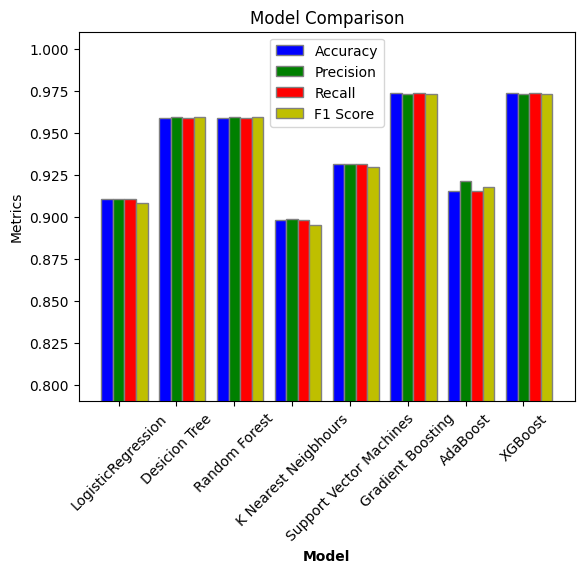

In [ ]:

# Number of models
n_models = len(Model_compare['Models'])

# Setting the positions and width for the bars
bar_width = 0.2
r1 = np.arange(n_models)
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Plotting the bars
plt.bar(r1, Model_compare['Accuracy'], color='b', width=bar_width, edgecolor='grey', label='Accuracy')
plt.bar(r2, Model_compare['Precision'], color='g', width=bar_width, edgecolor='grey', label='Precision')
plt.bar(r3, Model_compare['Recall'], color='r', width=bar_width, edgecolor='grey', label='Recall')
plt.bar(r4, Model_compare['F1_score'], color = 'y', width=bar_width, edgecolor = 'grey', label = 'F1 Score')

# Adding the xticks
plt.xlabel('Model', fontweight='bold')
plt.xticks([r + bar_width for r in range(n_models)], Model_compare['Models'])

# Adding labels and title
plt.ylabel('Metrics')
plt.title('Model Comparison')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limits
plt.ylim(0.79, 1.01)

# Show the plot
plt.show()